# Problem Set 02: Bank Marketing Term Deposit Prediction
## Logistic Regression Model

**Objective:** Build a Logistic Regression model to predict whether a customer will subscribe to a term deposit based on their banking behaviour and demographic information.

**Dataset:** Bank Marketing Data Set  
**Target Variable:** `y` — whether the client subscribed to a term deposit (`yes` / `no`)

---
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 2. Load the Dataset

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from google.colab import files
import zipfile
import io

print("Click 'Choose Files' and select bank-data.zip from your computer.")
uploaded = files.upload()

# Extract the CSV from the zip
zip_bytes = io.BytesIO(list(uploaded.values())[0])
with zipfile.ZipFile(zip_bytes, 'r') as z:
    print("Files inside zip:", z.namelist())
    csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file, sep=';', encoding='latin-1')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Click 'Choose Files' and select bank-data.zip from your computer.


Saving bank-data.zip to bank-data (1).zip
Files inside zip: ['bank-data/', '__MACOSX/._bank-data', 'bank-data/.DS_Store', '__MACOSX/bank-data/._.DS_Store', 'bank-data/bank-full.csv', '__MACOSX/bank-data/._bank-full.csv']
Dataset loaded successfully.
Shape: (45211, 17)


---
## 3. Exploratory Data Analysis (EDA)

In [8]:
# Display first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
# Statistical summary of numerical columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [12]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [13]:
# Distribution of the target variable
print("Target Variable Distribution:")
print(df['y'].value_counts())
print(f"\nClass balance ratio:")
print(df['y'].value_counts(normalize=True).round(4) * 100)

Target Variable Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Class balance ratio:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


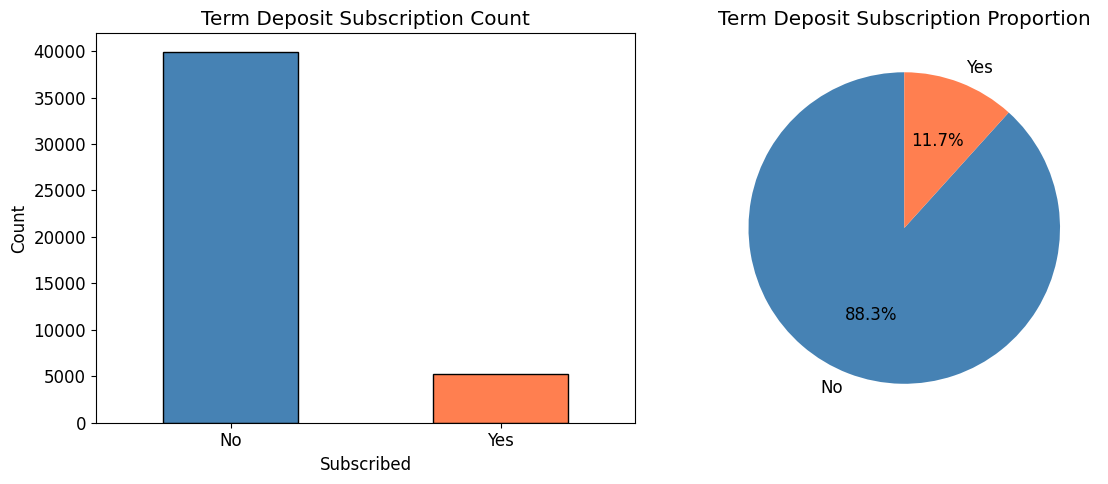

In [14]:
# Visualise target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Term Deposit Subscription Count')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

df['y'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                             colors=['steelblue', 'coral'], startangle=90,
                             labels=['No', 'Yes'])
axes[1].set_title('Term Deposit Subscription Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

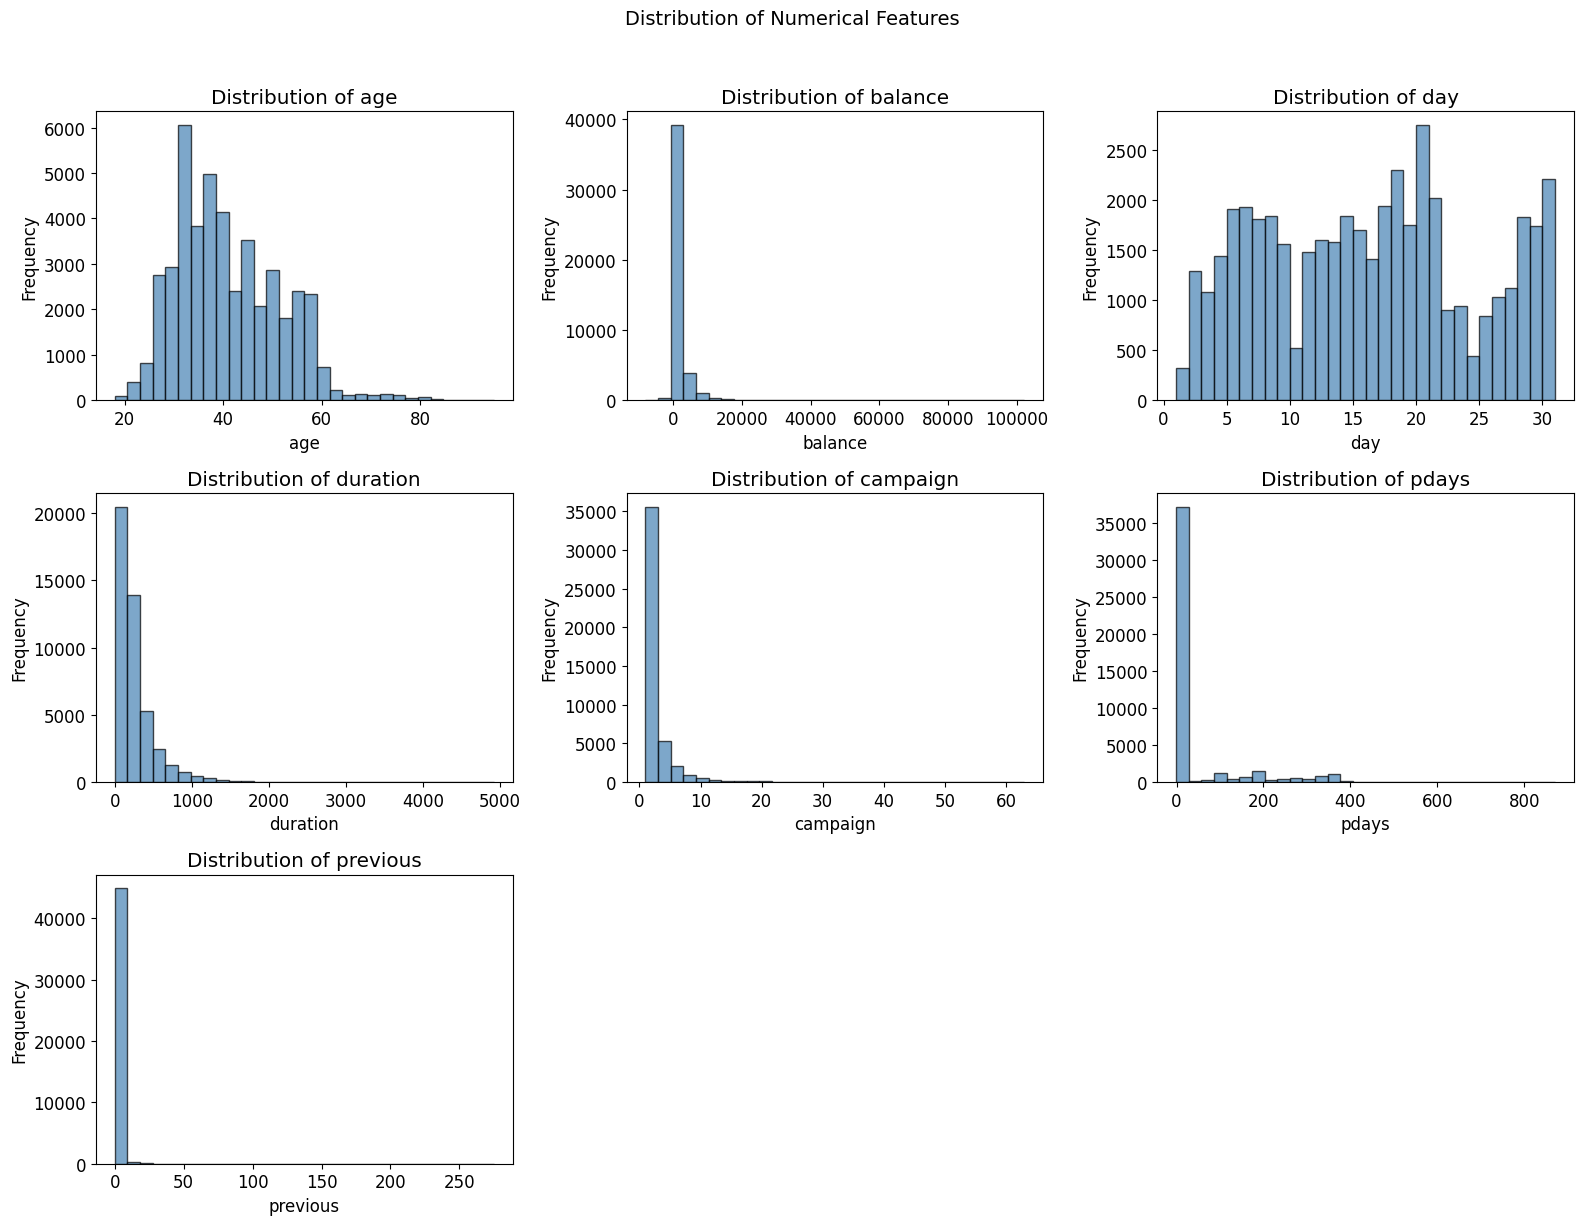

In [15]:
# Distribution of numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Categorical feature analysis
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'y']

print("Categorical Columns:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values -> {df[col].unique()[:5]}")

Categorical Columns:
  job: 12 unique values -> ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown']
  marital: 3 unique values -> ['married' 'single' 'divorced']
  education: 4 unique values -> ['tertiary' 'secondary' 'unknown' 'primary']
  default: 2 unique values -> ['no' 'yes']
  housing: 2 unique values -> ['yes' 'no']
  loan: 2 unique values -> ['no' 'yes']
  contact: 3 unique values -> ['unknown' 'cellular' 'telephone']
  month: 12 unique values -> ['may' 'jun' 'jul' 'aug' 'oct']
  poutcome: 4 unique values -> ['unknown' 'failure' 'other' 'success']


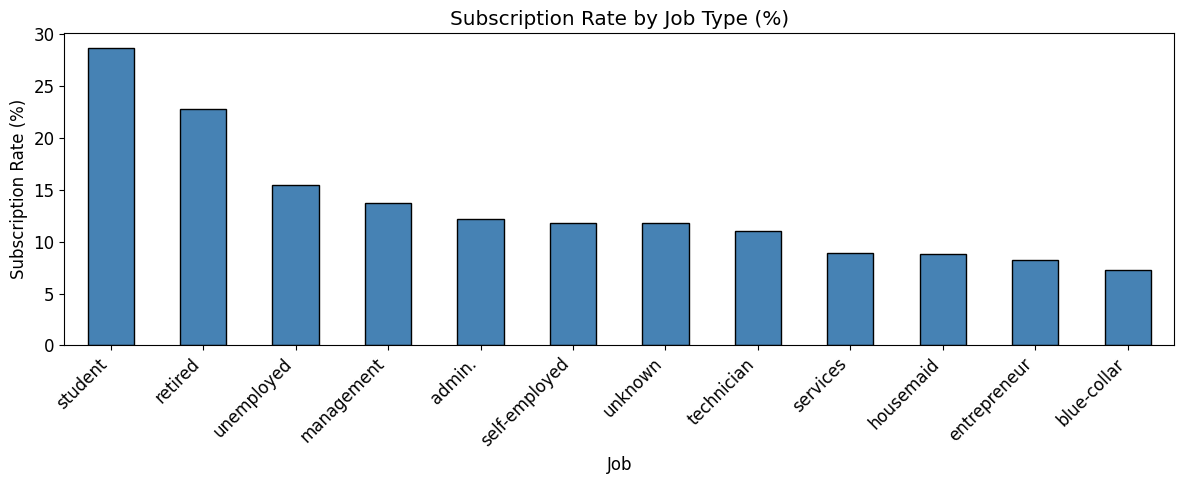

In [17]:
# Subscription rate by job
job_sub = df.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
job_sub.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Subscription Rate by Job Type (%)')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

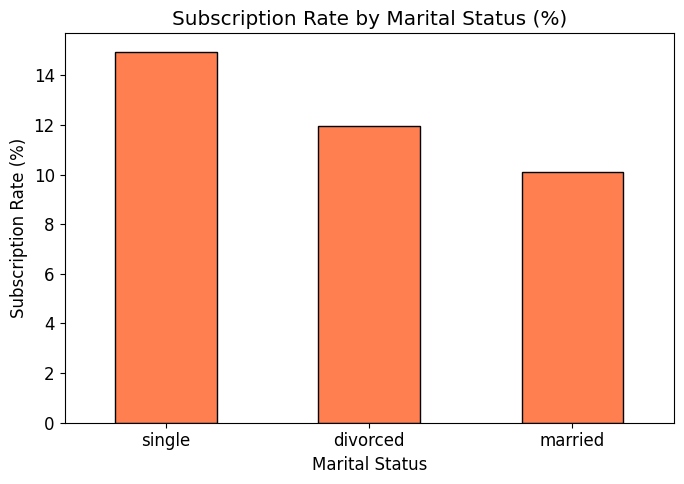

In [18]:
# Subscription rate by marital status
marital_sub = df.groupby('marital')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
marital_sub.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Subscription Rate by Marital Status (%)')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

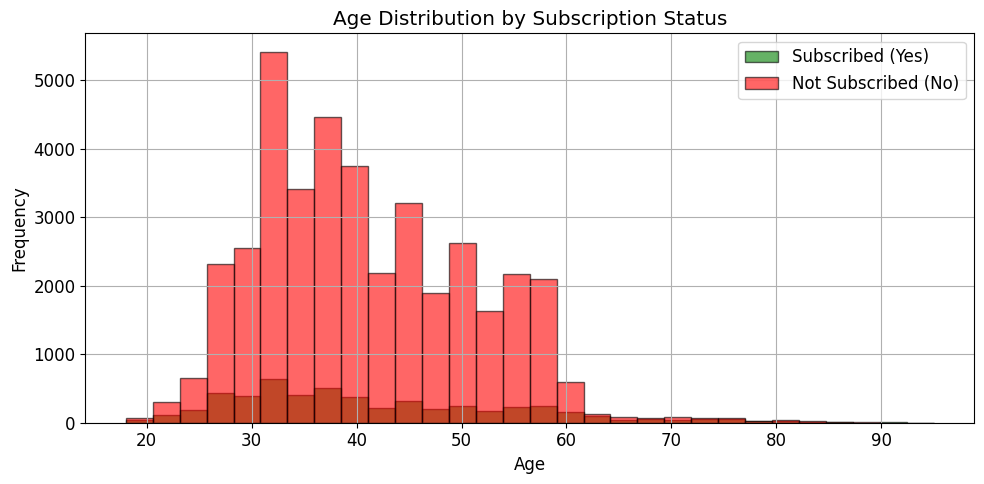

In [19]:
# Age distribution by subscription
plt.figure(figsize=(10, 5))
df[df['y'] == 'yes']['age'].hist(bins=30, alpha=0.6, color='green', label='Subscribed (Yes)', edgecolor='black')
df[df['y'] == 'no']['age'].hist(bins=30, alpha=0.6, color='red', label='Not Subscribed (No)', edgecolor='black')
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

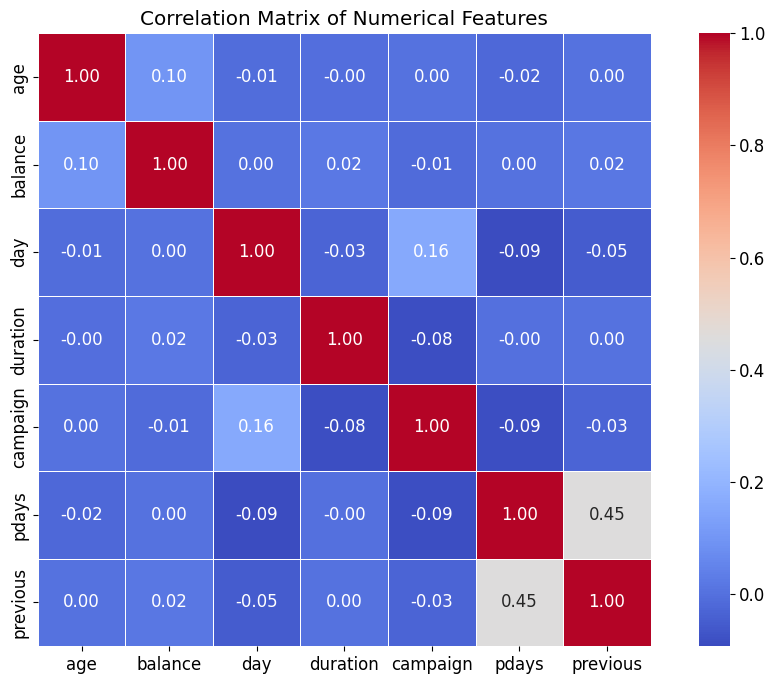

In [20]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 7))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [21]:
# Make a copy of the original dataframe
df_processed = df.copy()

print("Original shape:", df_processed.shape)

Original shape: (45211, 17)


In [22]:
# Drop duplicate rows if any
df_processed.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df_processed.shape)

Shape after removing duplicates: (45211, 17)


In [23]:
# Encode the target variable: yes -> 1, no -> 0
df_processed['y'] = df_processed['y'].map({'yes': 1, 'no': 0})

print("Target variable encoded:")
print(df_processed['y'].value_counts())

Target variable encoded:
y
0    39922
1     5289
Name: count, dtype: int64


In [24]:
# Encode categorical features using Label Encoding
le = LabelEncoder()
categorical_cols_to_encode = df_processed.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns to encode:", categorical_cols_to_encode)

for col in categorical_cols_to_encode:
    df_processed[col] = le.fit_transform(df_processed[col])
    print(f"  Encoded: {col}")

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
  Encoded: job
  Encoded: marital
  Encoded: education
  Encoded: default
  Encoded: housing
  Encoded: loan
  Encoded: contact
  Encoded: month
  Encoded: poutcome


In [25]:
# Verify all columns are now numeric
print("Data types after encoding:")
print(df_processed.dtypes)

Data types after encoding:
age          int64
job          int64
marital      int64
education    int64
default      int64
balance      int64
housing      int64
loan         int64
contact      int64
day          int64
month        int64
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome     int64
y            int64
dtype: object


In [26]:
# Separate features and target
X = df_processed.drop('y', axis=1)
y = df_processed['y']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (45211, 16)
Target shape: (45211,)

Feature columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [27]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print(f"\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training set size: 36168 samples
Testing set size:  9043 samples

Training target distribution:
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Testing target distribution:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


In [28]:
# Feature scaling using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Training set mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Training set std  (first 3 features): {X_train_scaled[:, :3].std(axis=0).round(4)}")

Features scaled successfully.
Training set mean (first 3 features): [-0. -0. -0.]
Training set std  (first 3 features): [1. 1. 1.]


---
## 5. Build the Logistic Regression Model

In [29]:
# Initialise and train the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model solver: {logistic_model.solver}")
print(f"Number of iterations: {logistic_model.n_iter_[0]}")

Logistic Regression model trained successfully.
Model solver: lbfgs
Number of iterations: 12


In [30]:
# Feature coefficients (log-odds)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))

Feature Coefficients (sorted by absolute value):
  Feature  Coefficient
 duration     1.028734
  contact    -0.567330
  housing    -0.516932
 campaign    -0.402560
    pdays     0.384912
     loan    -0.255830
 poutcome     0.248388
 previous     0.204413
education     0.140792
  marital     0.130995
    month     0.113827
      age     0.081924
  balance     0.062088
  default    -0.057444
      day    -0.037113
      job     0.031582


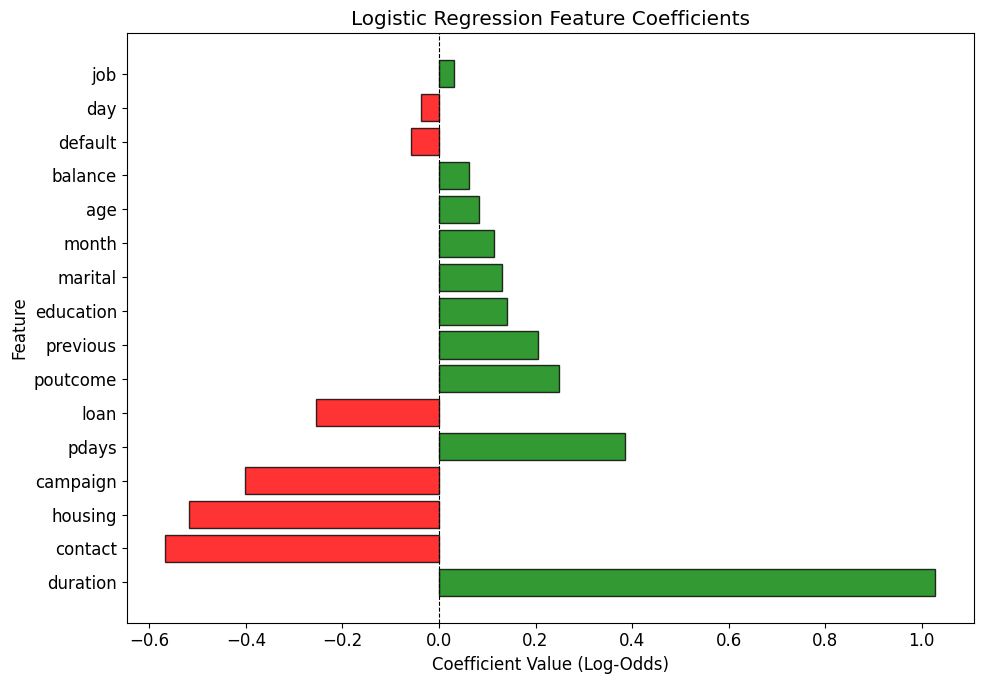

In [31]:
# Visualise feature coefficients
plt.figure(figsize=(10, 7))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value (Log-Odds)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 6. Model Evaluation

In [32]:
# Predictions on training and test sets
y_train_pred = logistic_model.predict(X_train_scaled)
y_test_pred  = logistic_model.predict(X_test_scaled)

# Predicted probabilities
y_test_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated.")

Predictions generated.


In [33]:
# Accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Training Accuracy: 0.8910 (89.10%)
Testing Accuracy:  0.8914 (89.14%)


In [34]:
# Detailed classification report
print("Classification Report (Test Set):")
print("-" * 60)
print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))

Classification Report (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.94      7985
     Yes (1)       0.59      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



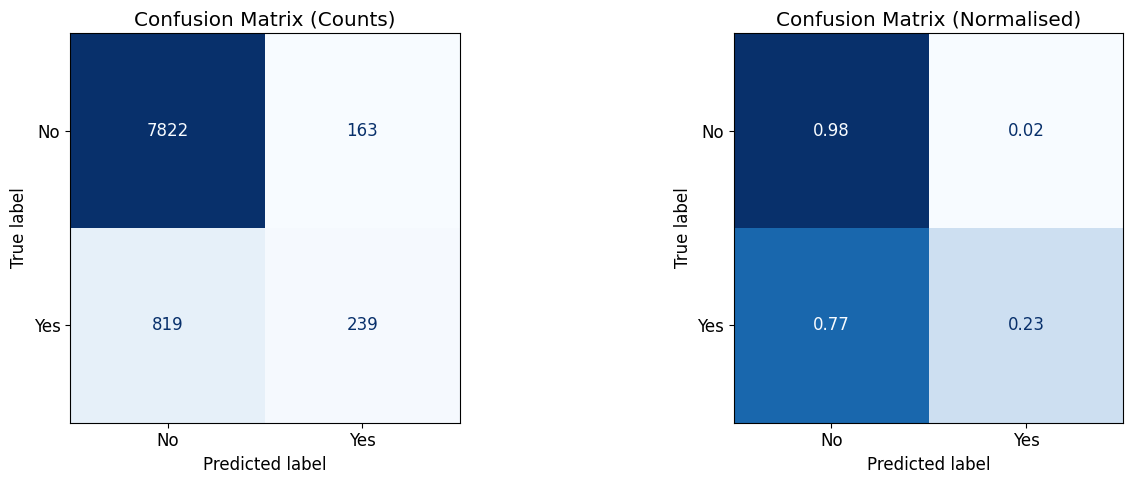


True Negatives  (TN): 7822
False Positives (FP): 163
False Negatives (FN): 819
True Positives  (TP): 239


In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalised
cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No', 'Yes'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalised)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

ROC-AUC Score: 0.8726


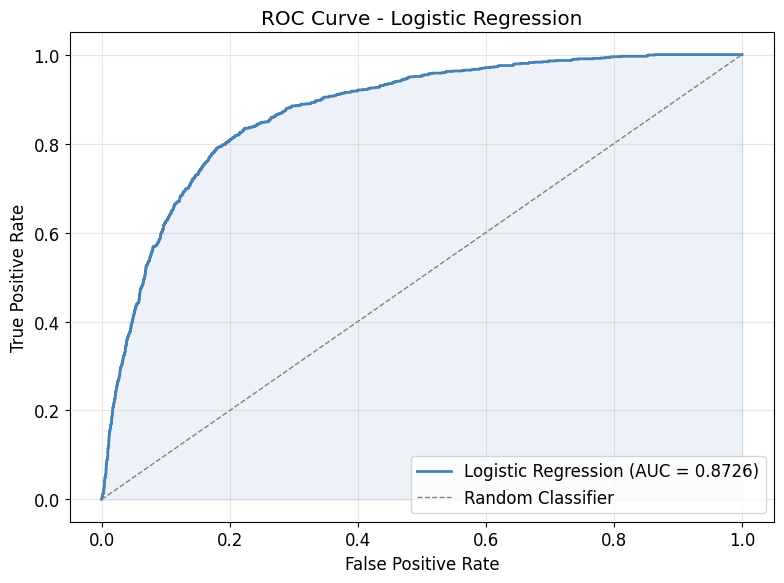

In [36]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_test_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Summary metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("Model Performance Summary")
print("=" * 40)
print(f"Accuracy:    {test_accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")

Model Performance Summary
Accuracy:    0.8914
Precision:   0.5945
Recall:      0.2259
F1-Score:    0.3274
Specificity: 0.9796
ROC-AUC:     0.8726


---
## 7. Prediction on New Data

The cell below demonstrates how to use the trained model to predict whether a new customer will subscribe to a term deposit.

In [38]:
# Example: Predict for a single new customer
# This uses the same feature order as the training data
sample_index = 0
sample_input = X_test_scaled[sample_index].reshape(1, -1)

predicted_class = logistic_model.predict(sample_input)[0]
predicted_prob  = logistic_model.predict_proba(sample_input)[0]

print(f"Predicted Class:               {'Yes (1) - Subscribed' if predicted_class == 1 else 'No (0) - Not Subscribed'}")
print(f"Probability of No  (class 0):  {predicted_prob[0]:.4f}")
print(f"Probability of Yes (class 1):  {predicted_prob[1]:.4f}")
print(f"\nActual label: {'Yes (1)' if y_test.iloc[sample_index] == 1 else 'No (0)'}")

Predicted Class:               No (0) - Not Subscribed
Probability of No  (class 0):  0.9882
Probability of Yes (class 1):  0.0118

Actual label: No (0)


---
## 8. Conclusion

In this notebook, a Logistic Regression model was built to predict whether a bank customer will subscribe to a term deposit.

**Key Steps Performed:**

1. Loaded and explored the Bank Marketing dataset comprising 17 attributes.
2. Performed EDA to understand the distribution of features, class imbalance, and relationships between variables.
3. Preprocessed the data by encoding categorical variables with Label Encoding and scaling numerical features with StandardScaler.
4. Split the data into 80% training and 20% testing sets with stratification to preserve class distribution.
5. Trained a Logistic Regression model and examined feature coefficients.
6. Evaluated the model using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC score.

**Observations:**

- The dataset is imbalanced, with the majority of customers not subscribing to a term deposit.
- Despite the class imbalance, Logistic Regression achieves a reasonable accuracy and ROC-AUC score.
- Features such as call duration, number of contacts, and previous campaign outcome have the most influence on the prediction.
- Further improvements can be explored through class balancing techniques (e.g., SMOTE), feature engineering, or more complex classification models.